# Multi-Store, Multi-Item Sales Forecasting with XGBoost and LightGBM

This notebook provides a full pipeline for daily, weekly, and monthly sales forecasting across multiple stores and items using XGBoost and LightGBM. It covers feature engineering, model training, forecasting, aggregation, evaluation, visualization, and saving outputs.

**BACKUP**

## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [1]:
!pip install xgboost
!pip install optuna

import pandas as pd
import numpy as np
import pickle
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.dates as mdates
import optuna
import random
import os

# Load processed data
with open('../../data/df_processed.pkl', 'rb') as f:
    df_scoped_processed = pickle.load(f)
df = df_scoped_processed['df_processed']

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['store_nbr', 'item_nbr', 'date'])

# -----------------------------
# Fix randomness for reproducibility
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# -----------------------------
# Add path to 'package' folder
# -----------------------------

import sys
import os

# Get the parent folder of the notebook
notebook_dir = os.getcwd()               # should be .../3_modeling
parent_dir = os.path.dirname(notebook_dir)  # go up one level

# Add the sibling folder 'package' to sys.path
sys.path.append(os.path.join(parent_dir, 'package'))

# Now you can import the module
from m_baseline_model import f_baseline_model
from m_metrics import f_asym_wmae, f_compute_metrics
from m_train_test_cutoff import f_split_time_series




[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: c:\Users\jasmi\Documents\2025_Data_analyse\202501_Ames_housing\.venv\Scripts\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0 -> 25.2
[notice] To update, run: c:\Users\jasmi\Documents\2025_Data_analyse\202501_Ames_housing\.venv\Scripts\python.exe -m pip install --upgrade pip


## 2. Feature Engineering: Lag, Rolling, Earthquake, Oil Price and Baseline Features

Create lag features, rolling mean features, and a baseline feature for each store/item using groupby and shift/rolling operations. Define FEATURES and TARGET variables.

In [2]:
#Earthquake feature engineering
df['earthquake_event'] = (df['magnitude'] > 0).astype(int)
df['days_since_earthquake'] = df['date'] - df.loc[df['earthquake_event'] == 1, 'date'].max()
df['days_since_earthquake'] = df['days_since_earthquake'].dt.days
df['days_since_earthquake'] = df['days_since_earthquake'].where(df['earthquake_event'] == 0, 0)
df['days_since_earthquake'] = df['days_since_earthquake'].clip(lower=0)


# Ensure full daily coverage for each store-item pair
date_range = pd.date_range(df['date'].min(), df['date'].max(), freq="D")


# Build full index of all store-item-date combinations
full_index = pd.MultiIndex.from_product(
    [df['store_nbr'].unique(), df['item_nbr'].unique(), date_range],
    names=['store_nbr','item_nbr','date']
)

# Aggregate once per store-item-date (ensures uniqueness)
df = (df.groupby(['store_nbr', 'item_nbr', 'date'], as_index=True)
        .agg({'unit_sales':'sum',
              'earthquake_event':'max',
              'days_since_earthquake':'max',
              'type_holiday':'first',
              'oil_price':'mean',
              'onpromotion':'last',  # or 'sum' depending on your logic
              'city':'first',
              'state':'first',
              'cluster':'first',
              'class':'first',
              'temperature_2m_max': 'max',
              'magnitude':'max',
              'salary_payment':'max'
        })
        .reindex(full_index)       # <-- reindex on full 3D index
        .reset_index())            # back to normal columns


# Convert categorical columns (if using XGBoost ≥ 1.6)
for col in ['city', 'state', 'cluster', 'class', 'type_holiday']:
    df[col] = df[col].astype('category')

# Now safely re-add date-based features
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Recreate holiday flag AFTER reindex
df['is_holiday'] = (df.get('type_holiday', "NO_HOLIDAY") != "NO_HOLIDAY").astype(int)

# Fill missing values
df['unit_sales'] = df['unit_sales'].fillna(0)   # assume no sales if missing
df['earthquake_event'] = df['earthquake_event'].fillna(0)
df['days_since_earthquake'] = df['days_since_earthquake'].fillna(method='ffill')
df['oil_price'] = df['oil_price'].fillna(method='ffill')

#Lag features and rolling means
LAGS = [1,7,14,28]
ROLLS = [7,14]

for lag in LAGS:
    df[f'lag_{lag}'] = df.groupby(['store_nbr','item_nbr'])['unit_sales'].shift(lag)
for roll in ROLLS:
    df[f'roll_mean_{roll}'] = df.groupby(['store_nbr','item_nbr'])['unit_sales'].shift(1).rolling(roll).mean()

# Roll_mean_28_lag28 feature: average sales from 29–56 days ago (relative to the current day)
df['roll_mean_28_lag28'] = df.groupby(['store_nbr','item_nbr'])['unit_sales'].shift(28).rolling(28).mean()

# Define features and target
EXTRA_FEATURES = ['days_since_earthquake', 'oil_price', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday']  # add more if needed
FEATURES = [f'lag_{lag}' for lag in LAGS] + [f'roll_mean_{roll}' for roll in ROLLS] + ['roll_mean_28_lag28'] + EXTRA_FEATURES
TARGET = 'unit_sales'

print(f'number of NaNs in features: {df[FEATURES].isna().sum().sum()}')


df_model = df


nan_counts = df_model.isna().sum()
nan_counts = nan_counts[nan_counts > 0]

print(f' NaNs broken down per feature: {nan_counts}')



nan_counts_per_group = df.groupby(['store_nbr','item_nbr'])[FEATURES].apply(lambda g: g.isna().sum())
print(nan_counts_per_group.head())



C:\Users\jasmi\AppData\Local\Temp\ipykernel_12660\94056024.py:55: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['days_since_earthquake'] = df['days_since_earthquake'].fillna(method='ffill')
C:\Users\jasmi\AppData\Local\Temp\ipykernel_12660\94056024.py:56: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['oil_price'] = df['oil_price'].fillna(method='ffill')


number of NaNs in features: 209664
 NaNs broken down per feature: type_holiday          499127
onpromotion           592212
city                  499127
state                 499127
cluster               499127
class                 499127
temperature_2m_max    499127
magnitude             499127
salary_payment        499127
lag_1                   1664
lag_7                  11648
lag_14                 23296
lag_28                 46592
roll_mean_7            11648
roll_mean_14           23296
roll_mean_28_lag28     91520
dtype: int64
                    lag_1  lag_7  lag_14  lag_28  roll_mean_7  roll_mean_14  \
store_nbr item_nbr                                                            
44        122095.0      1      7      14      28            7            14   
          123347.0      1      7      14      28            7            14   
          129635.0      1      7      14      28            7            14   
          158842.0      1      7      14      28            7 

## 3. Define final validation set and training set for cross validation

In [3]:
# Use helper function from module
df_trainval, df_test_final, cutoff_date = f_split_time_series(df_model, date_col="date", test_days=90)


Train/Val data: 2014-01-02 to 2017-05-17
Final Test data: 2017-05-18 to 2017-08-15


## 4. Hyperparameter Optimization with Cross-Validation (Disabled because of 45 min run time: Using Previously Saved Parameters)

In [ ]:
RUN_OPTUNA = True  # <-- set to True if you want to re-run tuning

if RUN_OPTUNA:

    # --- TimeSeriesSplit for Optuna ---
    dates = df_trainval.index.unique()
    tss = TimeSeriesSplit(n_splits=5, test_size=90, gap=7)


    # --- LightGBM Objective ---
    def objective_lgb(trial):
        params = {
            "objective": "regression",
            "seed": SEED,
            "metric": "rmse",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 31, 255),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
            "verbose": -1
        }
        scores = []
        for train_idx, val_idx in tss.split(dates):
            train_dates, val_dates = dates[train_idx], dates[val_idx]
            train, val = df_trainval[df_trainval.index.isin(train_dates)], df_trainval[df_trainval.index.isin(val_dates)]
            X_train, y_train = train[FEATURES], np.log1p(train[TARGET])
            X_val, y_val = val[FEATURES], np.log1p(val[TARGET])
            lgb_train = lgb.Dataset(X_train, label=y_train)
            lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
            model = lgb.train(params, lgb_train, valid_sets=[lgb_val],
                            num_boost_round=1000,
                            callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
            val_pred = model.predict(X_val, num_iteration=model.best_iteration)
            scores.append(np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred))))
            
        return np.mean(scores)

    # --- XGBoost Objective ---
    def objective_xgb(trial):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "seed": SEED,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),
            "verbosity": 0
        }
        scores = []
        for train_idx, val_idx in tss.split(dates):
            train_dates, val_dates = dates[train_idx], dates[val_idx]
            train, val = df_trainval[df_trainval.index.isin(train_dates)], df_trainval[df_trainval.index.isin(val_dates)]
            X_train, y_train = train[FEATURES], np.log1p(train[TARGET])
            X_val, y_val = val[FEATURES], np.log1p(val[TARGET])
            dtrain, dval = xgb.DMatrix(X_train, label=y_train), xgb.DMatrix(X_val, label=y_val)
            model = xgb.train(params, dtrain, num_boost_round=5000, evals=[(dval, "val")],
                            early_stopping_rounds=50, verbose_eval=False)
            val_pred = model.predict(dval, iteration_range=(0, model.best_iteration))
            scores.append(np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_pred))))
            
        return np.mean(scores)

    # --- Run Optuna Studies ---
    study_lgb = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
    study_lgb.optimize(objective_lgb, n_trials=20, show_progress_bar=True)
    study_xgb = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
    study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

    # --- Re-run CV with best params to get average best iteration ---
    best_iters_lgb, best_iters_xgb = [], []

    # LightGBM best iters
    for train_idx, val_idx in tss.split(dates):
        train_dates, val_dates = dates[train_idx], dates[val_idx]
        train, val = df_trainval[df_trainval.index.isin(train_dates)], df_trainval[df_trainval.index.isin(val_dates)]
        X_train, y_train = train[FEATURES], np.log1p(train[TARGET])
        X_val, y_val = val[FEATURES], np.log1p(val[TARGET])
        lgb_train = lgb.Dataset(X_train, label=y_train)
        lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)
        model = lgb.train(study_lgb.best_params, lgb_train, valid_sets=[lgb_val],
                        num_boost_round=2000,
                        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
        best_iters_lgb.append(model.best_iteration)

    # XGBoost best iters
    for train_idx, val_idx in tss.split(dates):
        train_dates, val_dates = dates[train_idx], dates[val_idx]
        train, val = df_trainval[df_trainval.index.isin(train_dates)], df_trainval[df_trainval.index.isin(val_dates)]
        X_train, y_train = train[FEATURES], np.log1p(train[TARGET])
        X_val, y_val = val[FEATURES], np.log1p(val[TARGET])
        dtrain, dval = xgb.DMatrix(X_train, label=y_train), xgb.DMatrix(X_val, label=y_val)
        model = xgb.train(study_xgb.best_params, dtrain, num_boost_round=5000,
                        evals=[(dval, "val")],
                        early_stopping_rounds=50, verbose_eval=False)
        best_iters_xgb.append(model.best_iteration)

    avg_best_iter_lgb = int(np.mean(best_iters_lgb))
    avg_best_iter_xgb = int(np.mean(best_iters_xgb))

    print("Average best iteration LGB:", avg_best_iter_lgb)
    print("Average best iteration XGB:", avg_best_iter_xgb)

    # Example: save best params after tuning
    best_params_lgb = study_lgb.best_params
    best_params_xgb = study_xgb.best_params

else:
    print("Skipping Optuna tuning. Using saved best_params.json.")

# Load best params if not running Optuna
if not RUN_OPTUNA:
    with open("best_params_90.json", "r") as f:
        best_params = json.load(f)
    best_params_lgb = best_params["lgb_90"]
    best_params_xgb = best_params["xgb_90"]


[I 2025-09-13 08:51:46,343] A new study created in memory with name: no-name-c30c45a5-7c4a-4ef9-904d-9a3db5aacc3a


  0%|          | 0/20 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[101]	valid_0's rmse: 0.764124
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[328]	valid_0's rmse: 0.509927
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[275]	valid_0's rmse: 0.507497
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[206]	valid_0's rmse: 0.658747
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[252]	valid_0's rmse: 0.542121
[I 2025-09-13 08:53:46,042] Trial 0 finished with value: 8.31994720084899 and parameters: {'learning_rate': 0.012051717418158098, 'num_leaves': 219, 'min_data_in_leaf': 49, 'feature_fraction': 0.9244865777082607, 'bagging_fraction': 0.6547775973299149, 'bagging_freq': 2}. Best is trial 0 with value: 8.31994720084899.
Training until validation scores don't improve

### Save lgb and xgb best parameters

In [ ]:
# Save to JSON
import json
with open("best_params_90.json", "w") as f:
    json.dump({"lgb_90": best_params_lgb, "xgb_90": best_params_xgb}, f)




NameError: name 'best_params_lgb' is not defined

## 5. Plot showing training/val set together with final test set

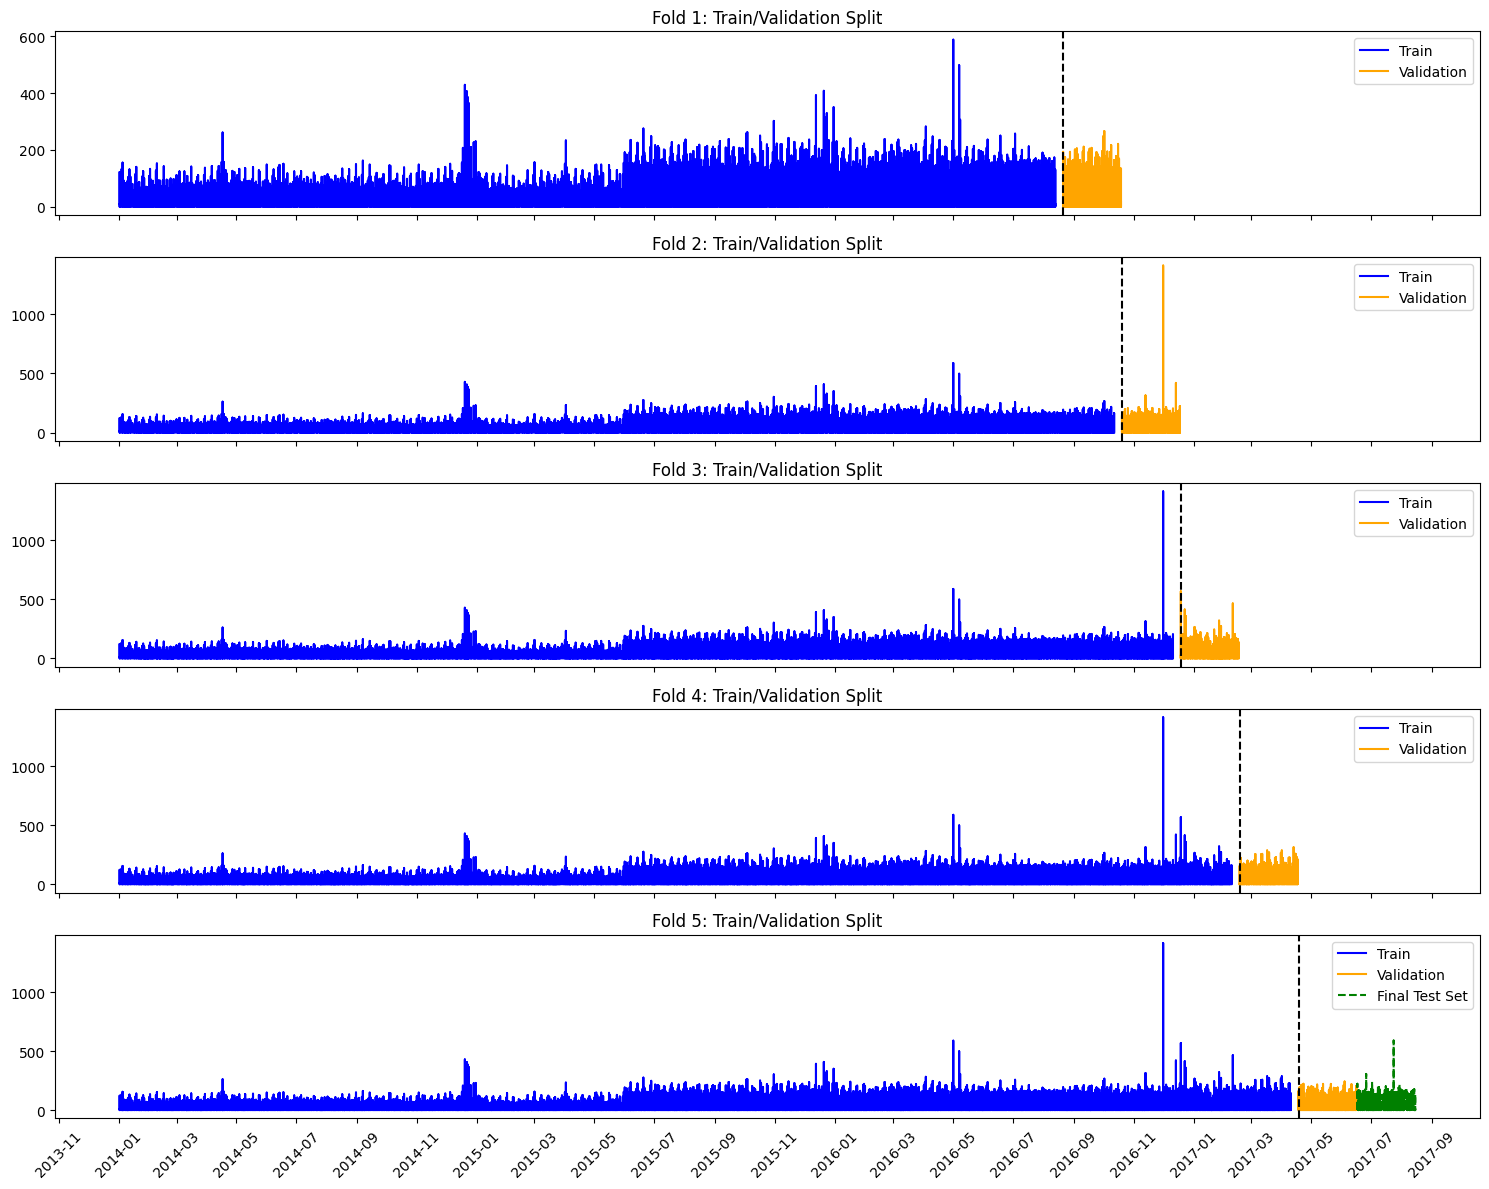

In [ ]:
# Plot setup
fig, axs = plt.subplots(tss.n_splits, 1, figsize=(15, 12), sharex=True)

for fold, (train_idx, val_idx) in enumerate(tss.split(dates)):
    train_dates = dates[train_idx]
    val_dates   = dates[val_idx]

    train = df_trainval[df_trainval.index.isin(train_dates)]
    val   = df_trainval[df_trainval.index.isin(val_dates)]

    axs[fold].plot(train.index, train['unit_sales'], label='Train', color='blue')
    axs[fold].plot(val.index, val['unit_sales'], label='Validation', color='orange')

    # Vertical line at validation start
    axs[fold].axvline(val.index.min(), color='black', linestyle='--')
    axs[fold].set_title(f'Fold {fold+1}: Train/Validation Split')
    axs[fold].legend()

# Plot the final test set on the last fold for context
axs[-1].plot(df_test_final.index, df_test_final['unit_sales'], 
             label='Final Test Set', color='green', linestyle='--')
axs[-1].legend()

# Format x-axis nicely
for ax in axs:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


for ax in axs:
    # Choose tick frequency (e.g., one tick per month)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # every 2 months
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)  # rotate labels for readability


plt.tight_layout()
plt.show()

## 6. Train on full trainval and validate on final test data

In [ ]:

# --- Load best hyperparameters ---
with open("best_params_90.json", "r") as f:
    best_params = json.load(f)

best_params_lgb = best_params["lgb_90"]
best_params_xgb = best_params["xgb_90"]

params_lgb_final = best_params_lgb.copy()
params_lgb_final.update({"objective": "regression", "metric": "rmse", "seed": SEED})

# --- Set average best iterations (from previous CV) ---
avg_best_iter_lgb = 33   # set from previous run
avg_best_iter_xgb = 318  # set from previous run

print("Loaded LGB params:", best_params_lgb)
print("Loaded XGB params:", best_params_xgb)
print("Using avg_best_iter_lgb:", avg_best_iter_lgb)
print("Using avg_best_iter_xgb:", avg_best_iter_xgb)




# --- Step 5: Final Models ---
X_trainval, y_trainval = df_trainval[FEATURES], np.log1p(df_trainval[TARGET])
X_test, y_test = df_test_final[FEATURES], np.log1p(df_test_final[TARGET])

# LightGBM Final Model
params_lgb_final.update({"objective": "regression", "metric": "rmse", "seed": SEED})
lgb_trainval = lgb.Dataset(X_trainval, label=y_trainval)
final_model_lgb = lgb.train(params_lgb_final, lgb_trainval, num_boost_round=avg_best_iter_lgb)

# XGBoost Final Model
params_xgb_final.update({"objective": "reg:squarederror", "eval_metric": "rmse", "seed": SEED})
xgb_trainval = xgb.DMatrix(X_trainval, label=y_trainval)
final_model_xgb = xgb.train(params_xgb_final, xgb_trainval, num_boost_round=avg_best_iter_xgb, verbose_eval=False)

# ---------------------------
# Final Evaluation on Test Set
# ---------------------------
# LightGBM
y_pred_lgb = final_model_lgb.predict(X_test)
rmse_final_lgb = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_lgb)))
mae_final_lgb = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_lgb))
print("Final Test LGB RMSE:", rmse_final_lgb)
print("Final Test LGB MAE:", mae_final_lgb)

# XGBoost
dtest = xgb.DMatrix(X_test)
y_pred_xgb = np.expm1(final_model_xgb.predict(dtest))
rmse_final_xgb = np.sqrt(mean_squared_error(np.expm1(y_test), y_pred_xgb))
mae_final_xgb = mean_absolute_error(np.expm1(y_test), y_pred_xgb)
print("Final Test XGB RMSE:", rmse_final_xgb)
print("Final Test XGB MAE:", mae_final_xgb)




Final Test LGB RMSE: 5.539680293592655
Final Test LGB MAE: 2.9915917370188896
Final Test XGB RMSE: 5.511504
Final Test XGB MAE: 2.9774537


## 7. Daily 7-Day Forecast per Store/Item - Light GBM

For each store/item, generate a 7-day daily forecast using the trained models, updating lag/rolling features iteratively.

In [ ]:
# To access the date as a column:
df_model = df_model.reset_index()
# Now df_model['date'] works again


# Define horizon for evaluation
future_horizon = 60
last_date = df_model['date'].max()
# Extract all unique store–item combinations, and put them in a DataFrame with two columns: store_nbr and item_nbr
stores_items = df_model.groupby(['store_nbr', 'item_nbr']).tail(1)[['store_nbr', 'item_nbr']]

# Build future dates DataFrame for baseline
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=future_horizon)
future_df = (
    stores_items.assign(key=1)
    .merge(pd.DataFrame({'date': future_dates, 'key': 1}), on='key')
    .drop('key', axis=1)
)

# Add unit_sales=0 just to satisfy function input
future_df['unit_sales'] = 0  

# Run baseline function
baseline_preds = f_baseline_model(
    pd.concat([df_model[['date','store_nbr','item_nbr','unit_sales']], future_df]))

# Keep only future part
baseline_preds = baseline_preds[baseline_preds['date'].isin(future_dates)]
baseline_preds = baseline_preds[['date','store_nbr','item_nbr','predicted_sales']]


# Forecasting loop
rows = []
for _, row in stores_items.iterrows():
    store = row['store_nbr']
    item = row['item_nbr']
    df_si = df_model[(df_model['store_nbr'] == store) & (df_model['item_nbr'] == item)]
    df_si = df_si.set_index('date').asfreq('D')  # force daily frequency
    df_si['unit_sales'] = df_si['unit_sales'].fillna(0)  # or ffill, depending on meaning
    history = df_si['unit_sales'].values
    
    if len(history) < max(max(LAGS), max(ROLLS), 28):
        continue  # skip if not enough history
    for day in range(1, future_horizon + 1):
        future_date = last_date + pd.Timedelta(days=day)
        X_pred = {}
        for lag in LAGS:
            X_pred[f'lag_{lag}'] = history[-lag]
        for roll in ROLLS:
            X_pred[f'roll_mean_{roll}'] = history[-roll:].mean()
        X_pred['roll_mean_28_lag28'] = history[-56:-28].mean()
        # --- Add extra features for the forecast date ---
        X_pred['days_since_earthquake'] = 0.0  # or your computed value
        X_pred['oil_price'] = 0.0  # or your estimated value
        # If you add more features, set them here
        X_pred['day_of_week'] = future_date.dayofweek
        X_pred['month'] = future_date.month
        X_pred['year'] = future_date.year
        X_pred['is_weekend'] = int(future_date.dayofweek in [5, 6])
        X_pred['is_holiday'] = 0  # or your holiday logic
        X_pred['earthquake_event']= 0 # or your computed value
        X_pred['onpromotion'] = 0
        X_pred['temperature_2m_max'] = 16
        X_pred['salary_payment'] = 0
        X_pred['city'] = df_si['city'].iloc[-1]
        X_pred['state'] = df_si['state'].iloc[-1]
        X_pred['cluster'] = df_si['cluster'].iloc[-1]
        X_pred['class'] = df_si['class'].iloc[-1]
        X_pred['magnitude'] = 0


        # Ensure all features are present and in correct order
        for feat in FEATURES:
            if feat not in X_pred:
                X_pred[feat] = 0.0  # or a sensible default

        X_pred_df = pd.DataFrame([X_pred])[FEATURES]
        pred_lgb = np.expm1(final_model_lgb.predict(X_pred_df))[0]
        
        pred_base = baseline_preds.loc[
        (baseline_preds['store_nbr'] == store) & (baseline_preds['item_nbr'] == item) & (baseline_preds['date'] == future_date), 'predicted_sales'].values[0]

       
        rows.append({
            'store_nbr': store,
            'item_nbr': item,
            'date': future_date,
            'pred_lgb': pred_lgb,
            'pred_baseline': pred_base
        })
        history = np.append(history, pred_lgb)

daily_forecast_lgb = pd.DataFrame(rows)
display(daily_forecast_lgb.head(21))

df_model = df_model.set_index('date').sort_index()

,store_nbr,item_nbr,date,pred_lgb,pred_baseline
0,51.0,958015.0,2017-08-16,4.248004,4.607143
1,51.0,958015.0,2017-08-17,3.152416,4.544572
2,51.0,958015.0,2017-08-18,3.429910,4.585729
3,51.0,958015.0,2017-08-19,5.172022,4.565369
4,51.0,958015.0,2017-08-20,6.401928,4.678655
5,51.0,958015.0,2017-08-21,4.155227,4.657296
6,51.0,958015.0,2017-08-22,3.840866,4.662840
7,51.0,958015.0,2017-08-23,3.887440,4.728585
8,51.0,958015.0,2017-08-24,3.086834,4.617422
9,51.0,958015.0,2017-08-25,3.714406,4.620523


## 8 Daily 7-Day Forecast per Store/Item - XGBoost

For each store/item, generate a 7-day daily forecast using the trained models, updating lag/rolling features iteratively.

In [ ]:
# To access the date as a column:
df_model = df_model.reset_index()
# Now df_model['date'] works again


# Define horizon for evaluation
future_horizon = 60
last_date = df_model['date'].max()
stores_items = df_model.groupby(['store_nbr', 'item_nbr']).tail(1)[['store_nbr', 'item_nbr']]

# Build future dates DataFrame for baseline
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),
                             periods=future_horizon)
future_df = (
    stores_items.assign(key=1)
    .merge(pd.DataFrame({'date': future_dates, 'key': 1}), on='key')
    .drop('key', axis=1))

# Add unit_sales=0 just to satisfy function input
future_df['unit_sales'] = 0  

# Run baseline function
baseline_preds = f_baseline_model(
    pd.concat([df_model[['date','store_nbr','item_nbr','unit_sales']], future_df]))

# Keep only future part
baseline_preds = baseline_preds[baseline_preds['date'].isin(future_dates)]
baseline_preds = baseline_preds[['date','store_nbr','item_nbr','predicted_sales']]

rows = []
for _, row in stores_items.iterrows():
    store = row['store_nbr']
    item = row['item_nbr']
    history = df_model[(df_model['store_nbr'] == store) & (df_model['item_nbr'] == item)]['unit_sales'].values
    if len(history) < max(max(LAGS), max(ROLLS), 28):
        continue  # skip if not enough history
    for day in range(1, future_horizon + 1):
        future_date = last_date + pd.Timedelta(days=day)
        X_pred = {}
        for lag in LAGS:
            X_pred[f'lag_{lag}'] = history[-lag]
        for roll in ROLLS:
            X_pred[f'roll_mean_{roll}'] = history[-roll:].mean()
        X_pred['baseline'] = history[-28:].mean()
        # --- Add extra features for the forecast date ---
        X_pred['days_since_earthquake'] = 0.0  # or your computed value
        X_pred['oil_price'] = 0.0  # or your estimated value
        # If you add more features, set them here
        X_pred['day_of_week'] = future_date.dayofweek
        X_pred['month'] = future_date.month
        X_pred['year'] = future_date.year
        X_pred['is_weekend'] = int(future_date.dayofweek in [5, 6])
        X_pred['is_holiday'] = 0  # or your holiday logic
        X_pred['earthquake_event']= 0 # or your computed value
        X_pred['onpromotion'] = 0
        X_pred['temperature_2m_max'] = 16
        X_pred['salary_payment'] = 0
        X_pred['city'] = df_si['city'].iloc[-1]
        X_pred['state'] = df_si['state'].iloc[-1]
        X_pred['cluster'] = df_si['cluster'].iloc[-1]
        X_pred['class'] = df_si['class'].iloc[-1]
        X_pred['magnitude'] = 0
        
        # Ensure all features are present and in correct order
        for feat in FEATURES:
            if feat not in X_pred:
                X_pred[feat] = 0.0  # or a sensible default

        X_pred_df = pd.DataFrame([X_pred])[FEATURES]
        pred_xgb = np.expm1(final_model_xgb.predict(xgb.DMatrix(X_pred_df)))[0]
        pred_base = baseline_preds.loc[
        (baseline_preds['store_nbr'] == store) & (baseline_preds['item_nbr'] == item) & (baseline_preds['date'] == future_date), 'predicted_sales'].values[0]
             
       
        rows.append({
            'store_nbr': store,
            'item_nbr': item,
            'date': future_date,
            'pred_xgb': pred_xgb,
            'pred_baseline': pred_base
        })
        history = np.append(history, pred_xgb)

daily_forecast_xgb = pd.DataFrame(rows)
display(daily_forecast_xgb.head(21))

,store_nbr,item_nbr,date,pred_xgb,pred_baseline
0,51.0,958015.0,2017-08-16,4.376491,4.607143
1,51.0,958015.0,2017-08-17,3.040581,4.549160
2,51.0,958015.0,2017-08-18,3.452045,4.586324
3,51.0,958015.0,2017-08-19,4.821948,4.566754
4,51.0,958015.0,2017-08-20,5.774245,4.667538
5,51.0,958015.0,2017-08-21,3.937335,4.623761
6,51.0,958015.0,2017-08-22,3.560065,4.621522
7,51.0,958015.0,2017-08-23,3.974675,4.677239
8,51.0,958015.0,2017-08-24,2.884331,4.569192
9,51.0,958015.0,2017-08-25,3.564675,4.565062


## 9 Aggregate Weekly and Monthly Forecasts - LGB

Aggregate the daily forecasts to weekly and monthly totals for higher-level reporting.

In [ ]:
# 1. Make sure your daily_forecast_lgb covers at least the next 60 days
# (Set future_horizon = 60 or more when generating daily_forecast_lgb).

# 2. Filter for the next 2 weeks and 2 months
today = daily_forecast_lgb['date'].min()
end_2weeks = today + pd.Timedelta(days=13)
end_2months = today + pd.DateOffset(months=2) - pd.Timedelta(days=1)

# Next 2 weeks forecast (for warehouse)
df_2weeks = daily_forecast_lgb[(daily_forecast_lgb['date'] >= today) & (daily_forecast_lgb['date'] <= end_2weeks)].copy()
df_2weeks['week'] = df_2weeks['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_forecast_2weeks_lgb = df_2weeks.groupby(['store_nbr', 'week'])[['pred_lgb']].sum().reset_index()

# Next 2 months forecast (for procurement)
df_2months = daily_forecast_lgb[(daily_forecast_lgb['date'] >= today) & (daily_forecast_lgb['date'] <= end_2months)].copy()
df_2months['month'] = df_2months['date'].dt.to_period('M').apply(lambda r: r.start_time)
monthly_forecast_2months_lgb = df_2months.groupby(['item_nbr', 'month'])[['pred_lgb']].sum().reset_index()

## 10. Aggregate Weekly and Monthly Forecasts - XGB

Aggregate the daily forecasts to weekly and monthly totals for higher-level reporting.

In [ ]:
# 1. Make sure your daily_forecast_xgb covers at least the next 60 days
# (Set future_horizon = 60 or more when generating daily_forecast_xgb)

# 2. Filter for the next 2 weeks and 2 months
today = daily_forecast_xgb['date'].min()
end_2weeks = today + pd.Timedelta(days=13)
end_2months = today + pd.DateOffset(months=2) - pd.Timedelta(days=1)

# Next 2 weeks forecast (for warehouse)
df_2weeks = daily_forecast_xgb[(daily_forecast_xgb['date'] >= today) & (daily_forecast_xgb['date'] <= end_2weeks)].copy()
df_2weeks['week'] = df_2weeks['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_forecast_2weeks_xgb = df_2weeks.groupby(['store_nbr', 'week'])[['pred_xgb']].sum().reset_index()

# Next 2 months forecast (for procurement)
df_2months = daily_forecast_xgb[(daily_forecast_xgb['date'] >= today) & (daily_forecast_xgb['date'] <= end_2months)].copy()
df_2months['month'] = df_2months['date'].dt.to_period('M').apply(lambda r: r.start_time)
monthly_forecast_2months_xgb = df_2months.groupby(['item_nbr', 'month'])[['pred_xgb']].sum().reset_index()

## 11. Compute and Display DAILY / WEEKLY/ MONTHLY Metrics - BASELINE, LGB, XGB

Define and compute evaluation metrics (RMSE, MAE, MAPE, Asymmetric WMAE) comparing forecasts to actuals.

In [ ]:

# Predict on test set (vectorized, fast)
df_test_final['pred_lgb'] = np.expm1(final_model_lgb.predict(X_test))
df_test_final['pred_xgb'] = np.expm1(final_model_xgb.predict(xgb.DMatrix(X_test)))
df_test_final['pred_baseline'] = df_test_final['baseline']


# 2. Weekly metrics (per store, per week: sum items)
test_weekly = df_test_final.reset_index().copy()

test_weekly['week'] = test_weekly['date'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_agg = test_weekly.groupby(['store_nbr', 'week'])[[TARGET, 'pred_lgb', 'pred_xgb','pred_baseline']].sum().reset_index()

metrics_weekly_lgb = f_compute_metrics(weekly_agg[TARGET], weekly_agg['pred_lgb'])
metrics_weekly_xgb = f_compute_metrics(weekly_agg[TARGET], weekly_agg['pred_xgb'])
metrics_weekly_baseline = f_compute_metrics(weekly_agg[TARGET], weekly_agg['pred_baseline'])

# 3. Monthly metrics (per item, per month: sum stores)
test_weekly['month'] = test_weekly['date'].dt.to_period('M').apply(lambda r: r.start_time)
monthly_agg = test_weekly.groupby(['item_nbr', 'month'])[[TARGET, 'pred_lgb','pred_xgb','pred_baseline']].sum().reset_index()

metrics_monthly_lgb = f_compute_metrics(monthly_agg[TARGET], monthly_agg['pred_lgb'])
metrics_monthly_xgb = f_compute_metrics(monthly_agg[TARGET], monthly_agg['pred_xgb'])
metrics_monthly_baseline = f_compute_metrics(monthly_agg[TARGET], monthly_agg['pred_baseline'])

# 4. Show all metrics in a table
metrics_all = pd.DataFrame(
    [
        f_compute_metrics(df_test_final[TARGET], df_test_final['pred_lgb']),
        f_compute_metrics(df_test_final[TARGET], df_test_final['pred_xgb']),
        f_compute_metrics(df_test_final[TARGET], df_test_final['pred_baseline']),
        metrics_weekly_lgb,
        metrics_weekly_xgb,
        metrics_weekly_baseline,
        metrics_monthly_lgb,
        metrics_monthly_xgb,
        metrics_monthly_baseline
    ],
    index=[
        'Daily_LightGBM', 'Daily_XGBoost', 'Daily_Baseline',
        'Weekly_LightGBM', 'Weekly_XGBoost','Weekly_Baseline',
        'Monthly_LightGBM', 'Monthly_XGBoost','Monthly_Baseline'
    ]
)
display(metrics_all)

,RMSE,MAE,MAPE,Asym_WMAE
Daily_LightGBM,5.539680,2.991592,3.311755e+06,2.650841
Daily_XGBoost,5.511504,2.977454,5.038277e+06,2.731564
Daily_Baseline,6.886636,4.090947,3.927029e+07,3.962072
Weekly_LightGBM,1212.238170,1027.725645,9.811217e+00,997.662566
Weekly_XGBoost,1166.732056,1001.478027,9.700384e+00,973.133817
Weekly_Baseline,1311.523563,1082.171429,1.205781e+01,1129.712779
Monthly_LightGBM,224.265768,143.846740,1.050426e+07,124.293441
Monthly_XGBoost,211.931229,140.483856,3.176179e+06,124.746649
Monthly_Baseline,439.818260,257.595810,1.271268e+09,260.056858


## 8. Plot Forecasts - BASELINE, LGB, XGB


Plot total daily, weekly, and monthly forecasts using matplotlib for visual inspection.

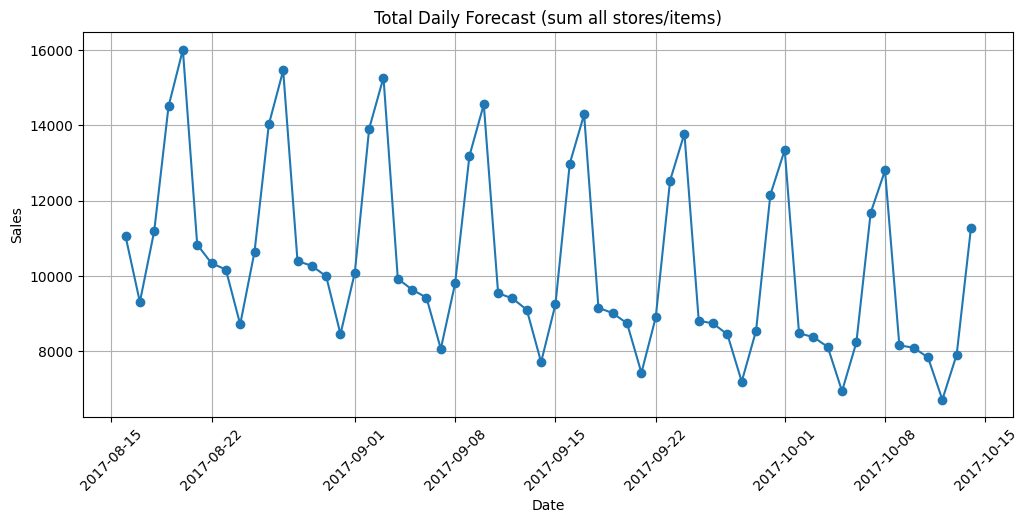

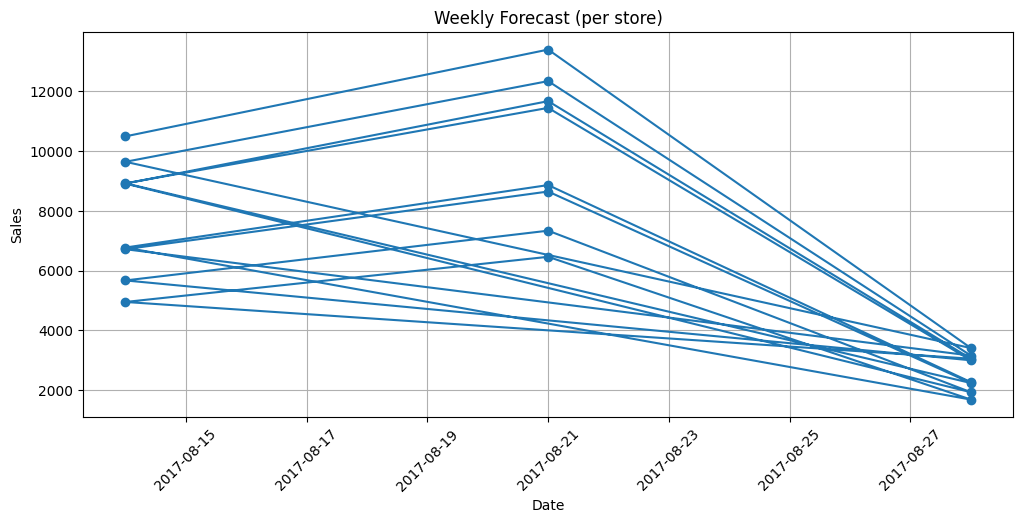

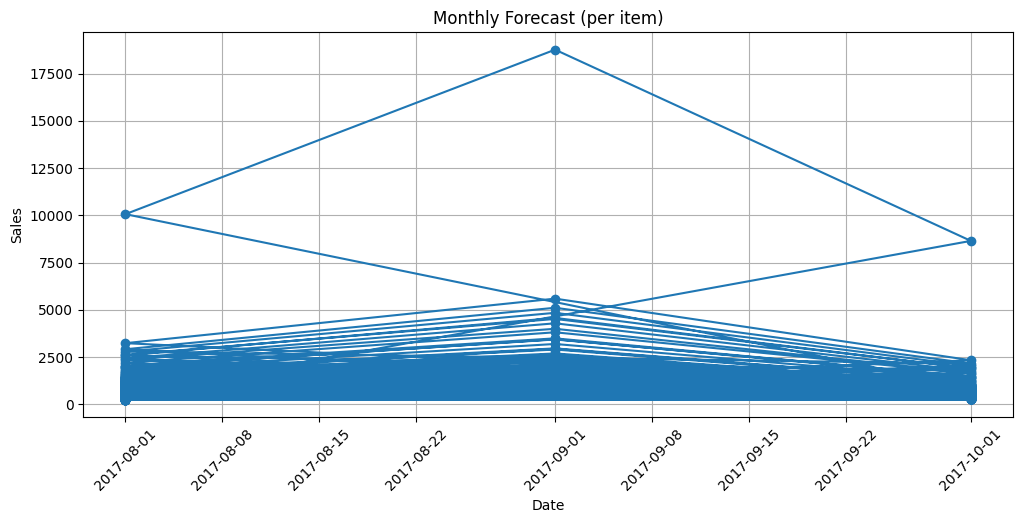

In [ ]:
def plot_forecast(df_forecast, date_col='date', value_col='pred_lgb', title='Forecast'):
    plt.figure(figsize=(12, 5))
    plt.plot(df_forecast[date_col], df_forecast[value_col], marker='o')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

# Plot total daily forecast
plot_forecast(daily_forecast_lgb.groupby('date')['pred_lgb'].sum().reset_index(), title='Total Daily Forecast (sum all stores/items)')

# Plot weekly forecast
plot_forecast(weekly_forecast_2weeks_lgb, date_col='week', title='Weekly Forecast (per store)')

# Plot monthly forecast
plot_forecast(monthly_forecast_2months_lgb, date_col='month', title='Monthly Forecast (per item)')

## 8.2 Plot Daily Total Sales + Forecasts - BASELINE, LGB, XGB

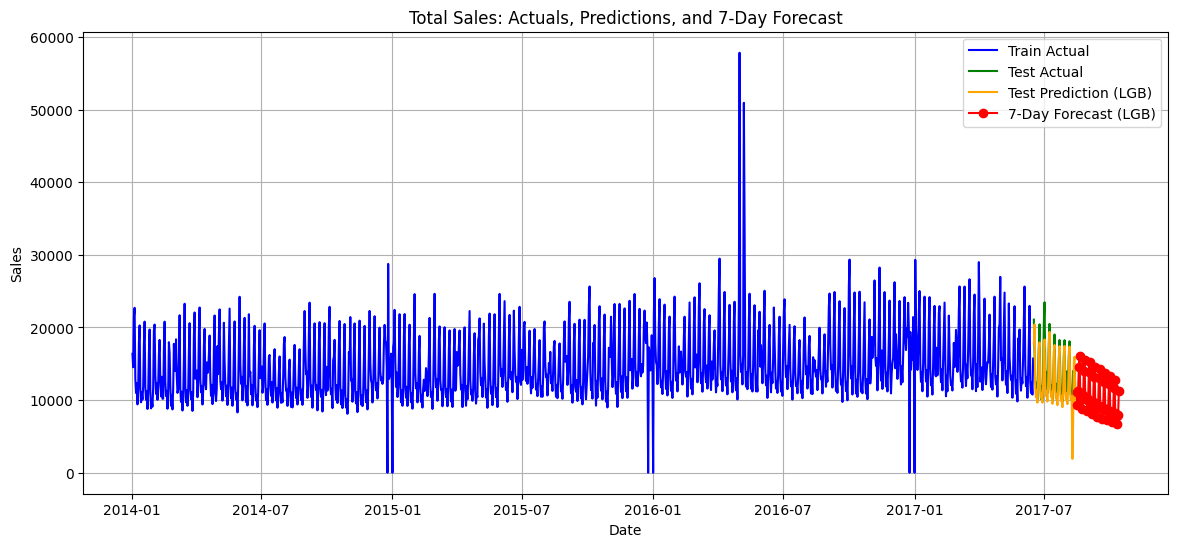

In [ ]:
# Plot total sales: actuals (train/test), test predictions, and forecast

train_total = df_trainval.groupby('date')['unit_sales'].sum().reset_index()
test_total = df_test_final.groupby('date')[['unit_sales', 'pred_lgb']].sum().reset_index()
forecast_total = daily_forecast_lgb.groupby('date')['pred_lgb'].sum().reset_index()

plt.figure(figsize=(14, 6))
plt.plot(train_total['date'], train_total['unit_sales'], label='Train Actual', color='blue')
plt.plot(test_total['date'], test_total['unit_sales'], label='Test Actual', color='green')
plt.plot(test_total['date'], test_total['pred_lgb'], label='Test Prediction (LGB)', color='orange')
plt.plot(forecast_total['date'], forecast_total['pred_lgb'], label='7-Day Forecast (LGB)', color='red', marker='o')

plt.title('Total Sales: Actuals, Predictions, and 7-Day Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 8.3 Plot Daily Total Sales + Forecasts for an ITEM/STORE combination - BASELINE, LGB, XGB

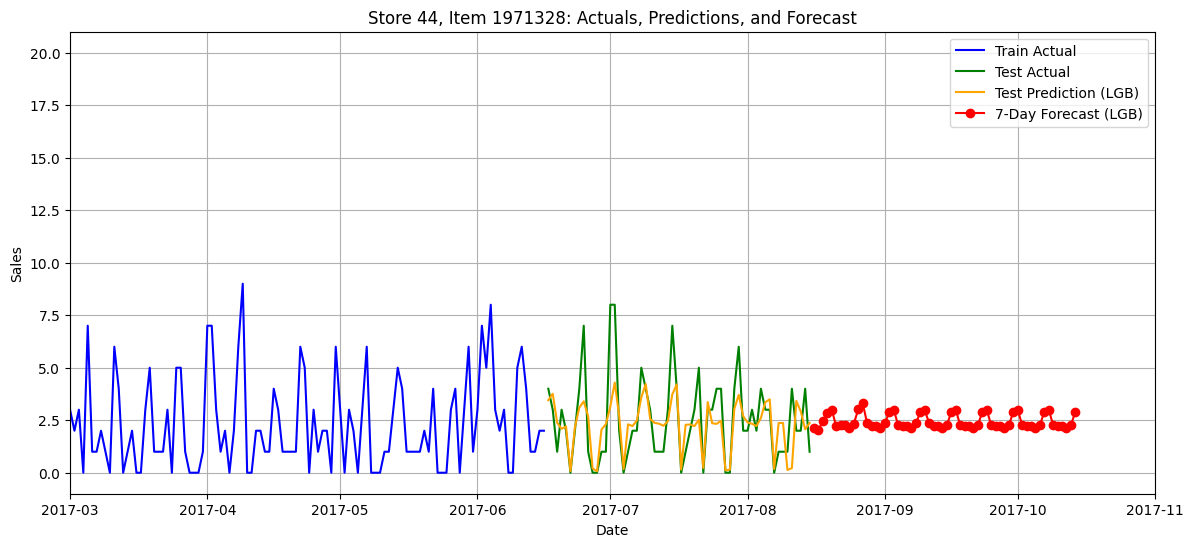

In [ ]:
# Plot actuals and predictions for train, test, and forecast for a single store/item
from datetime import datetime
store_id = 44
item_id = 1971328

# Get data for this store/item
df_train = df_trainval[(df_trainval['store_nbr'] == store_id) & (df_trainval['item_nbr'] == item_id)].copy()
df_test = df_test_final[(df_test_final['store_nbr'] == store_id) & (df_test_final['item_nbr'] == item_id)].copy()
df_forecast_lgb = daily_forecast_lgb[(daily_forecast_lgb['store_nbr'] == store_id) & (daily_forecast_lgb['item_nbr'] == item_id)].copy()
df_train = df_train.reset_index().copy()
df_test = df_test.reset_index().copy()
df_forecast_lgb = df_forecast_lgb.reset_index().copy()

plt.figure(figsize=(14, 6))


plt.plot(df_train['date'], df_train['unit_sales'], label='Train Actual', color='blue')
plt.plot(df_test['date'], df_test['unit_sales'], label='Test Actual', color='green')
plt.plot(df_test['date'], df_test['pred_lgb'], label='Test Prediction (LGB)', color='orange')
plt.plot(df_forecast_lgb['date'], df_forecast_lgb['pred_lgb'], label='7-Day Forecast (LGB)', color='red', marker='o')

plt.title(f'Store {store_id}, Item {item_id}: Actuals, Predictions, and Forecast')
plt.xlabel('Date')
plt.xlim(left=datetime(2017, 3, 1), right=datetime(2017,11,1) )
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

## 9. Save Forecast Outputs

Save the daily, weekly, and monthly forecast DataFrames to CSV files for downstream use.

In [ ]:
daily_forecast_lgb.to_csv('../data/daily_forecast_lgb.csv', index=False)
weekly_forecast_2weeks_lgb.to_csv('../data/weekly_forecast_lgb.csv', index=False)
monthly_forecast_2months_lgb.to_csv('../data/monthly_forecast_lgb.csv', index=False)

daily_forecast_xgb.to_csv('../data/daily_forecast_xgb.csv', index=False)
weekly_forecast_2weeks_xgb.to_csv('../data/weekly_forecast_xgb.csv', index=False)
monthly_forecast_2months_xgb.to_csv('../data/monthly_forecast_xgb.csv', index=False)


OSError: Cannot save file into a non-existent directory: '..\data'